# 🏙️ NYC Airbnb Open Data — Exploratory Data Analysis
* **Author:** Aya Nabil Saleem Alharazin :)
* **Dataset:** [NYC Airbnb Open Data](https://www.kaggle.com/dgomonov/new-york-city-airbnb-open-data)  
* **Tools:** Python · Pandas · Matplotlib · Seaborn · Plotly  

---
## Objective
This notebook performs a comprehensive EDA to uncover pricing patterns, 
geographic insights, host behavior, and listing quality across NYC boroughs.

# Phase 0 — Imports and Setup

In [1]:
# ─── Core ───────────────────────────────────────────────
import numpy as np
import pandas as pd

# ─── Visualization ──────────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go

# ─── Settings ───────────────────────────────────────────
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.2f}'.format)

sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.titleweight'] = 'bold'

import warnings
warnings.filterwarnings('ignore')

print("✅ All libraries loaded successfully")

✅ All libraries loaded successfully


# 📘 Phase 1 — Data Understanding and Quality

In [2]:
# ── 1.1 Load ────────────────────────────────────────────
df = pd.read_csv('/kaggle/input/datasets/dgomonov/new-york-city-airbnb-open-data/AB_NYC_2019.csv')
print(f"Shape: {df.shape}")
df.head()

Shape: (48895, 16)


,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
0,2539,Clean & quiet apt home by the park,2787,John,Brooklyn,Kensington,40.65,-73.97,Private room,149,1,9,2018-10-19,0.21,6,365
1,2595,Skylit Midtown Castle,2845,Jennifer,Manhattan,Midtown,40.75,-73.98,Entire home/apt,225,1,45,2019-05-21,0.38,2,355
2,3647,THE VILLAGE OF HARLEM....NEW YORK !,4632,Elisabeth,Manhattan,Harlem,40.81,-73.94,Private room,150,3,0,NaN,NaN,1,365
3,3831,Cozy Entire Floor of Brownstone,4869,LisaRoxanne,Brooklyn,Clinton Hill,40.69,-73.96,Entire home/apt,89,1,270,2019-07-05,4.64,1,194
4,5022,Entire Apt: Spacious Studio/Loft by central park,7192,Laura,Manhattan,East Harlem,40.80,-73.94,Entire home/apt,80,10,9,2018-11-19,0.10,1,0


In [3]:
# ── 1.2 Structure ────────────────────────────────────────
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48895 entries, 0 to 48894
Data columns (total 16 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              48895 non-null  int64  
 1   name                            48879 non-null  object 
 2   host_id                         48895 non-null  int64  
 3   host_name                       48874 non-null  object 
 4   neighbourhood_group             48895 non-null  object 
 5   neighbourhood                   48895 non-null  object 
 6   latitude                        48895 non-null  float64
 7   longitude                       48895 non-null  float64
 8   room_type                       48895 non-null  object 
 9   price                           48895 non-null  int64  
 10  minimum_nights                  48895 non-null  int64  
 11  number_of_reviews               48895 non-null  int64  
 12  last_review                     

In [4]:
# ── 1.3 Missing Values ───────────────────────────────────
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({'Missing Count': missing, 
                            'Missing %': missing_pct})
missing_df[missing_df['Missing Count'] > 0].sort_values('Missing %', ascending=False)

,Missing Count,Missing %
reviews_per_month,10052,20.56
last_review,10052,20.56
host_name,21,0.04
name,16,0.03


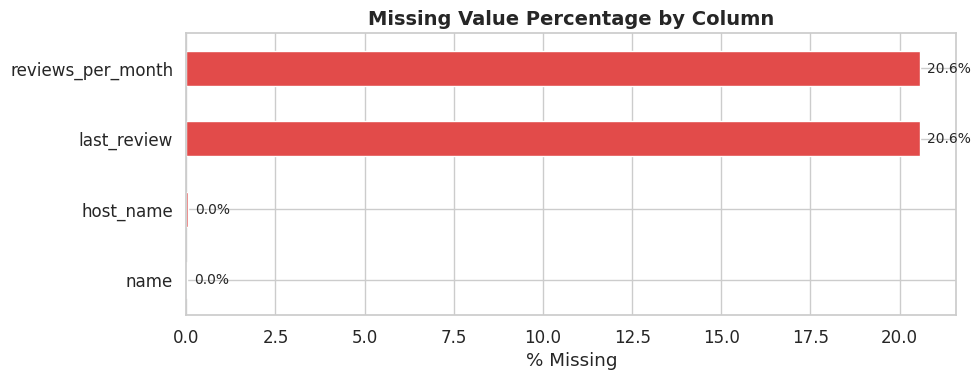

In [5]:
# ── 1.4 Visualize Missing Values ─────────────────────────
fig, ax = plt.subplots(figsize=(10, 4))
missing_pct[missing_pct > 0].sort_values().plot(
    kind='barh', ax=ax, color='#E24B4A'
)
ax.set_title('Missing Value Percentage by Column')
ax.set_xlabel('% Missing')
for bar in ax.patches:
    ax.text(bar.get_width() + 0.2, bar.get_y() + bar.get_height()/2,
            f'{bar.get_width():.1f}%', va='center', fontsize=10)
plt.tight_layout()
plt.show()

In [6]:
# ── 1.5 Duplicates ───────────────────────────────────────
print(f"Duplicate rows: {df.duplicated().sum()}")
print(f"Duplicate IDs: {df['id'].duplicated().sum()}")

Duplicate rows: 0
Duplicate IDs: 0


In [7]:
# ── 1.6 Fix Data Types ───────────────────────────────────
df['last_review'] = pd.to_datetime(df['last_review'])

# Insight: last_review and reviews_per_month share the same 10052 missing rows
# → listings that have never been reviewed
df['never_reviewed'] = df['last_review'].isna()
print(f"Listings never reviewed: {df['never_reviewed'].sum()} "
      f"({df['never_reviewed'].mean()*100:.1f}%)")

Listings never reviewed: 10052 (20.6%)


# 📊 Phase 2 — Univariate Analysis (Numerical)

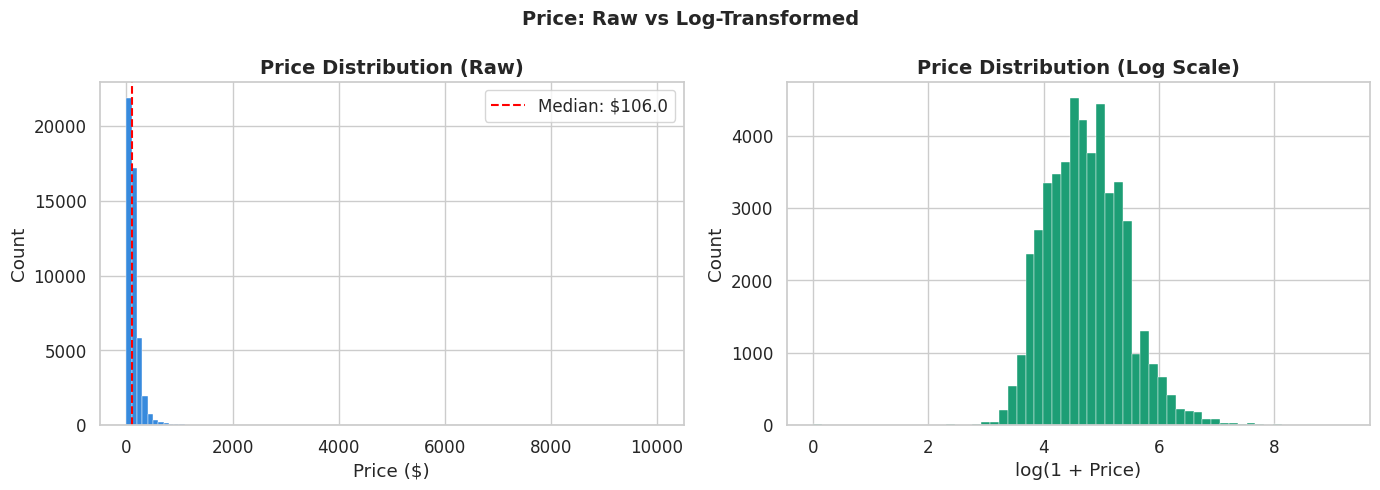

Skewness (raw):           19.12
Skewness (log-transform): 0.55


In [8]:
# ── 2.1 Price Distribution ───────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Raw (skewed)
axes[0].hist(df['price'], bins=100, color='#378ADD', edgecolor='white', linewidth=0.3)
axes[0].set_title('Price Distribution (Raw)')
axes[0].set_xlabel('Price ($)')
axes[0].set_ylabel('Count')
axes[0].axvline(df['price'].median(), color='red', 
                linestyle='--', label=f"Median: ${df['price'].median()}")
axes[0].legend()

# Log-transformed
axes[1].hist(np.log1p(df['price']), bins=60, color='#1D9E75', edgecolor='white', linewidth=0.3)
axes[1].set_title('Price Distribution (Log Scale)')
axes[1].set_xlabel('log(1 + Price)')
axes[1].set_ylabel('Count')

plt.suptitle('Price: Raw vs Log-Transformed', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print(f"Skewness (raw):           {df['price'].skew():.2f}")
print(f"Skewness (log-transform): {np.log1p(df['price']).skew():.2f}")

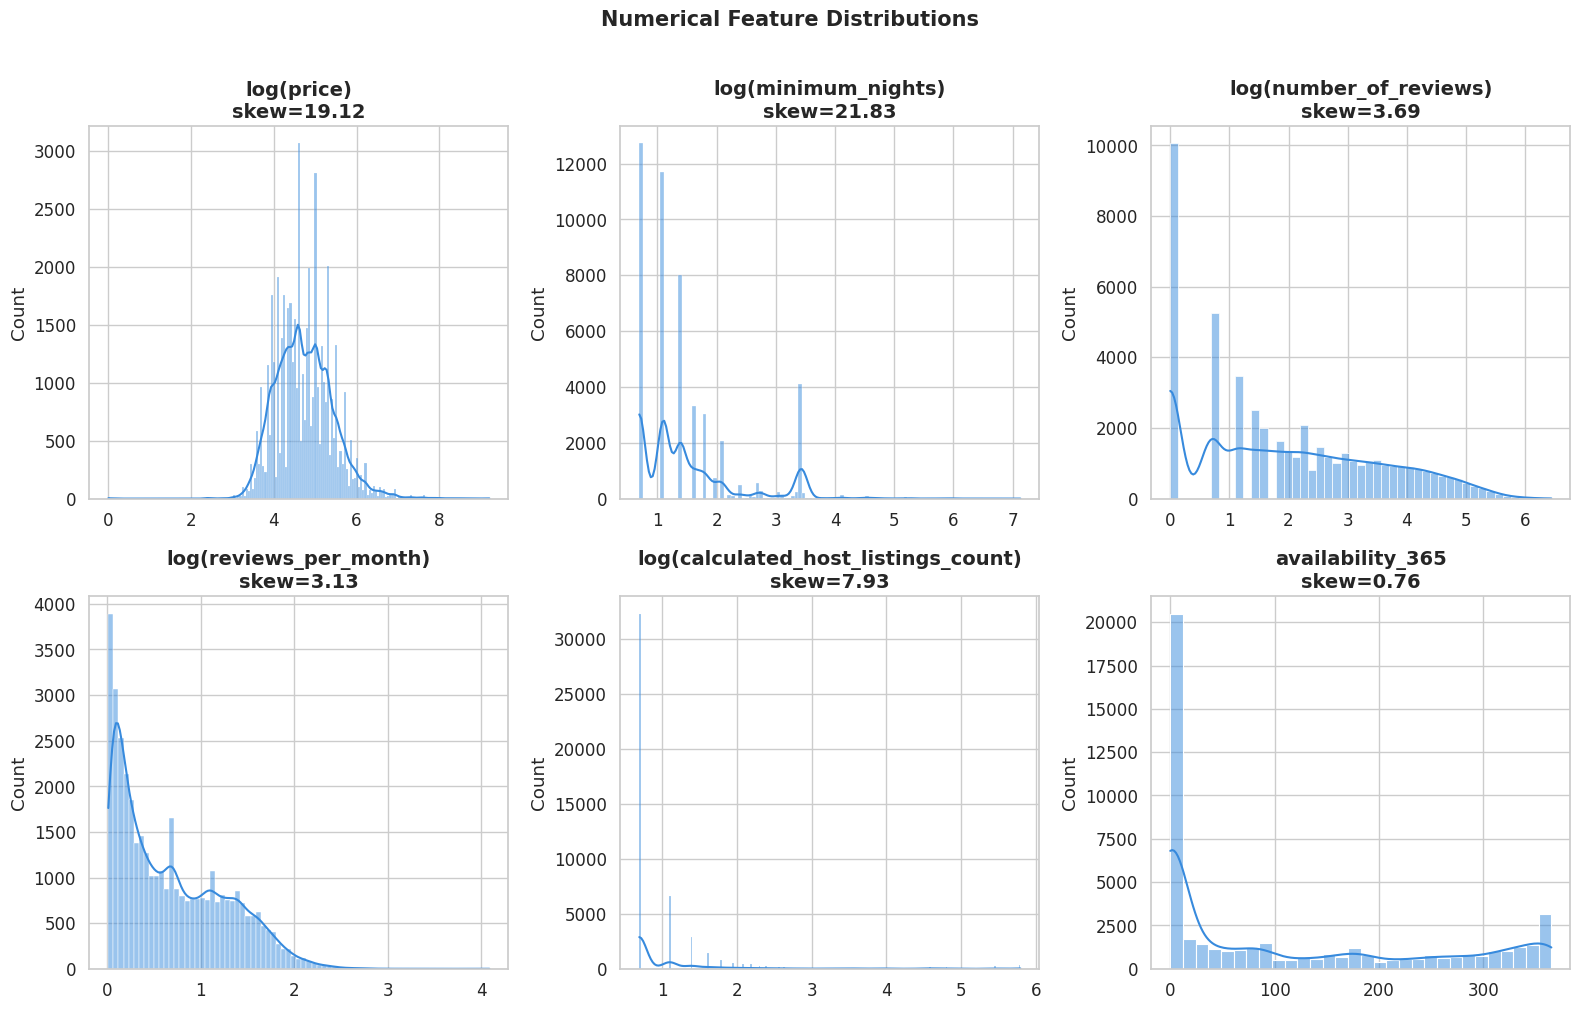

In [9]:
# ── 2.2 Key Numerical Distributions ─────────────────────
num_cols = ['price', 'minimum_nights', 'number_of_reviews', 
            'reviews_per_month', 'calculated_host_listings_count', 
            'availability_365']

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    data = np.log1p(df[col].dropna()) if df[col].skew() > 1 else df[col].dropna()
    label = f'log({col})' if df[col].skew() > 1 else col
    sns.histplot(data, ax=axes[i], kde=True, color='#378ADD')
    axes[i].set_title(f'{label}\nskew={df[col].skew():.2f}')
    axes[i].set_xlabel('')

plt.suptitle('Numerical Feature Distributions', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

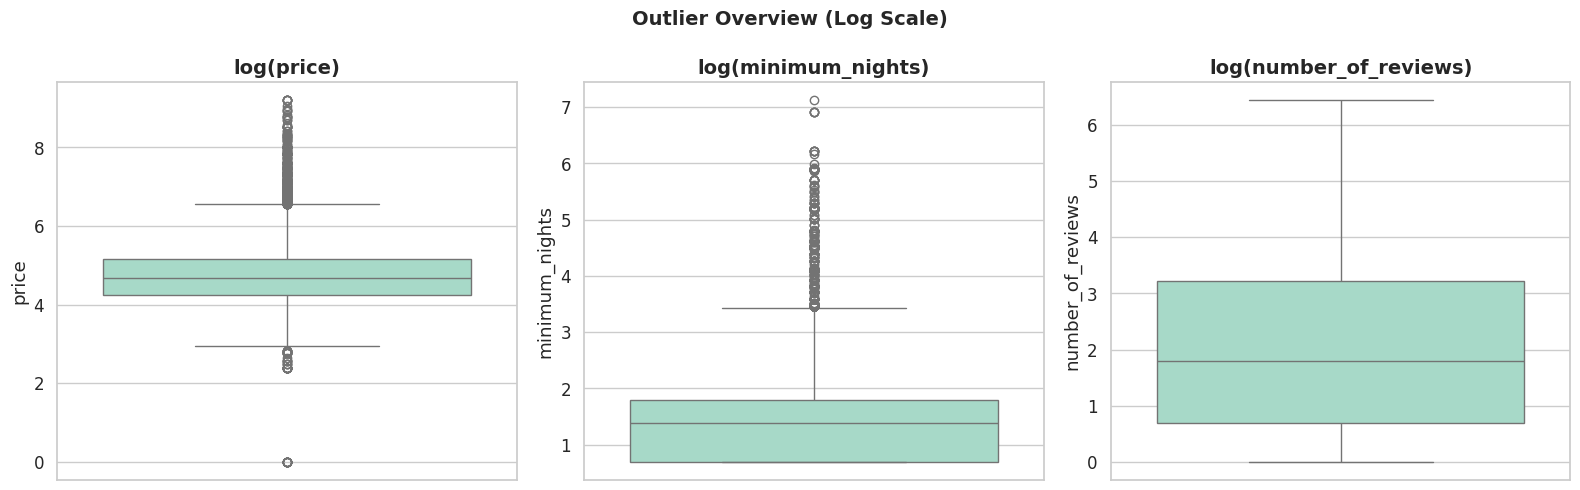

In [10]:
# ── 2.3 Boxplots for Outlier Overview ────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for i, col in enumerate(['price', 'minimum_nights', 'number_of_reviews']):
    sns.boxplot(y=np.log1p(df[col]), ax=axes[i], color='#9FE1CB')
    axes[i].set_title(f'log({col})')

plt.suptitle('Outlier Overview (Log Scale)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# 🏷️ Phase 3 — Categorical Analysis

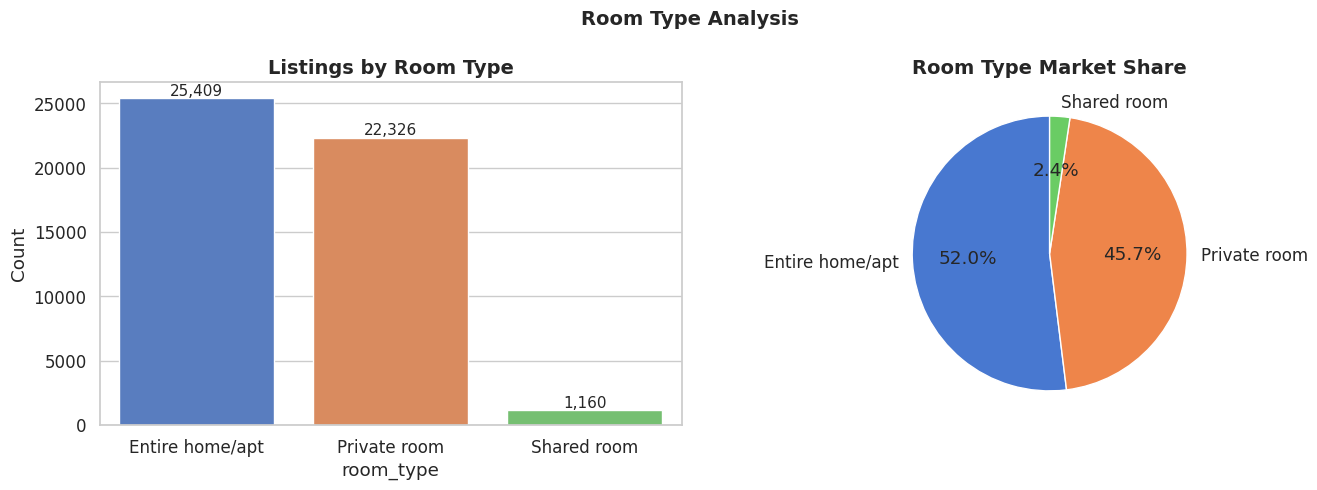

In [11]:
# ── 3.1 Room Type Distribution ───────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

room_counts = df['room_type'].value_counts()

# Bar chart
sns.barplot(x=room_counts.index, y=room_counts.values, 
            ax=axes[0], palette='muted')
axes[0].set_title('Listings by Room Type')
axes[0].set_ylabel('Count')
for bar in axes[0].patches:
    axes[0].text(bar.get_x() + bar.get_width()/2, 
                 bar.get_height() + 200,
                 f'{bar.get_height():,.0f}', ha='center', fontsize=11)

# Pie chart
axes[1].pie(room_counts.values, labels=room_counts.index, autopct='%1.1f%%',
            colors=sns.color_palette('muted'), startangle=90)
axes[1].set_title('Room Type Market Share')

plt.suptitle('Room Type Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

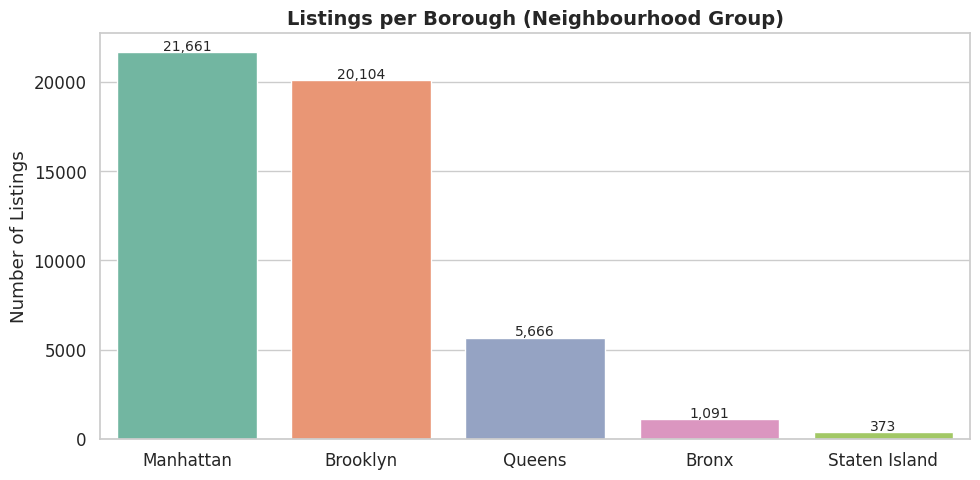

In [12]:
# ── 3.2 Borough Distribution ─────────────────────────────
borough_counts = df['neighbourhood_group'].value_counts()

fig, ax = plt.subplots(figsize=(10, 5))
bars = sns.barplot(x=borough_counts.index, y=borough_counts.values, 
                   palette='Set2', ax=ax)
ax.set_title('Listings per Borough (Neighbourhood Group)')
ax.set_ylabel('Number of Listings')
ax.set_xlabel('')
for bar in ax.patches:
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 100,
            f'{bar.get_height():,.0f}', ha='center', fontsize=10)
plt.tight_layout()
plt.show()

* Business Insight: Manhattan and Brooklyn dominate the market. This tells you where competition is highest and where pricing power may differ.

# 🔗 Phase 4 — Bivariate Analysis

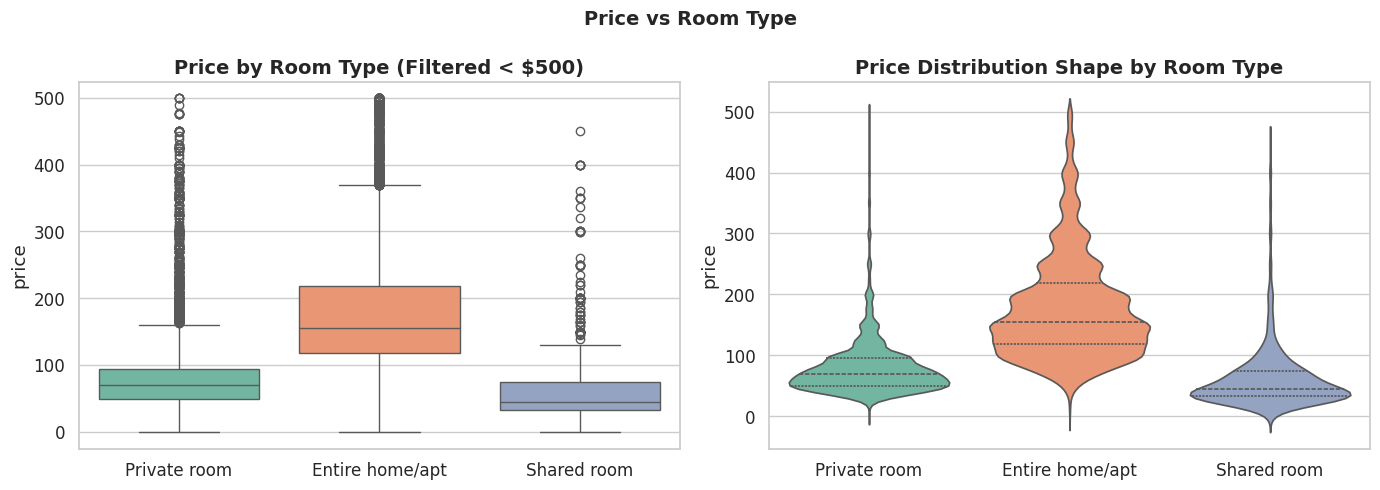

In [13]:
# ── 4.1 Price by Room Type ────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Boxplot
sns.boxplot(data=df[df['price'] < 500], x='room_type', y='price',
            ax=axes[0], palette='Set2')
axes[0].set_title('Price by Room Type (Filtered < $500)')
axes[0].set_xlabel('')

# Violin — shows distribution shape
sns.violinplot(data=df[df['price'] < 500], x='room_type', y='price',
               ax=axes[1], palette='Set2', inner='quartile')
axes[1].set_title('Price Distribution Shape by Room Type')
axes[1].set_xlabel('')

plt.suptitle('Price vs Room Type', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

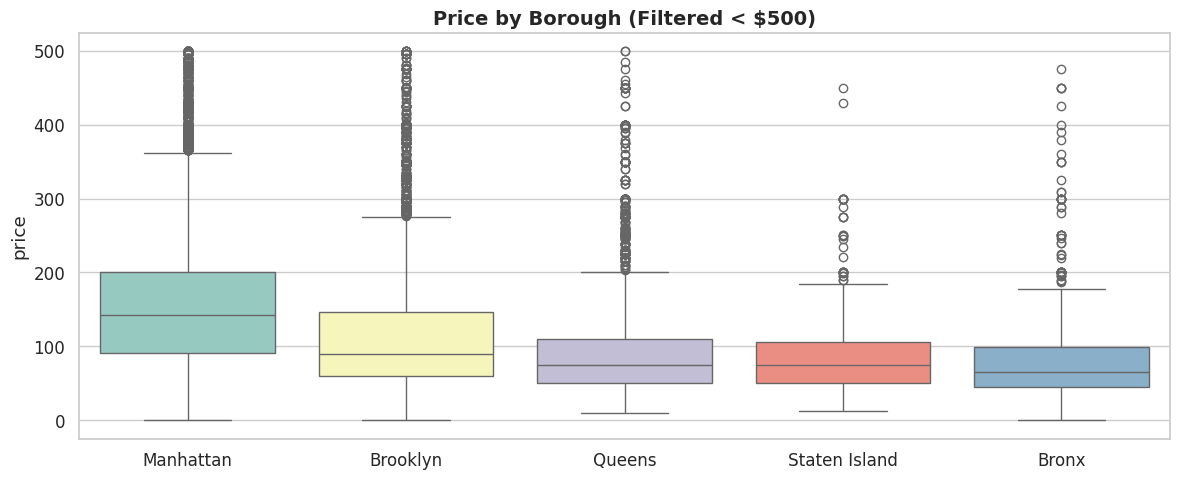

In [14]:
# ── 4.2 Price by Borough ──────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 5))

order = df.groupby('neighbourhood_group')['price'].median().sort_values(ascending=False).index
sns.boxplot(data=df[df['price'] < 500], x='neighbourhood_group', y='price',
            order=order, palette='Set3', ax=ax)
ax.set_title('Price by Borough (Filtered < $500)')
ax.set_xlabel('')
plt.tight_layout()
plt.show()

In [15]:
# ── 4.3 Reviews vs Price Scatter ──────────────────────────
fig = px.scatter(
    df[df['price'] < 500].sample(3000, random_state=42),
    x='number_of_reviews', y='price',
    color='room_type', opacity=0.5,
    title='Number of Reviews vs Price (Sample 3000)',
    labels={'number_of_reviews': 'Number of Reviews', 'price': 'Price ($)'},
    color_discrete_sequence=px.colors.qualitative.Set2
)
fig.update_layout(template='plotly_white')
fig.show()

* 🔥 Phase 5 — Correlation and Multivariate Analysis

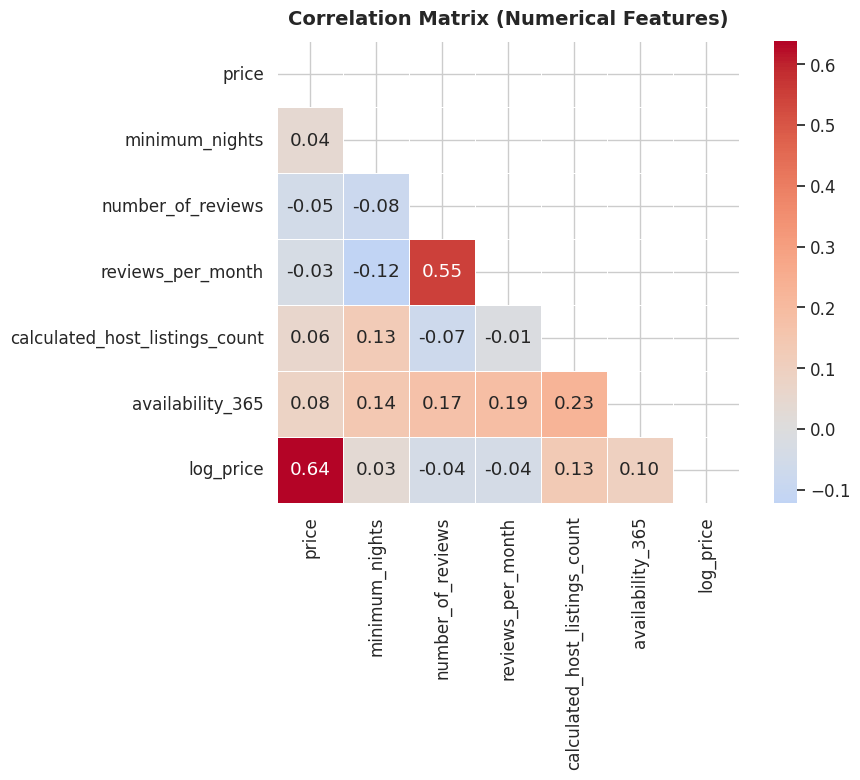

In [16]:
# ── 5.1 Correlation Heatmap ───────────────────────────────
num_df = df[['price','minimum_nights','number_of_reviews',
             'reviews_per_month','calculated_host_listings_count',
             'availability_365']].copy()
num_df['log_price'] = np.log1p(df['price'])

corr = num_df.corr()

fig, ax = plt.subplots(figsize=(10, 8))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f',
            cmap='coolwarm', center=0, ax=ax,
            linewidths=0.5, square=True)
ax.set_title('Correlation Matrix (Numerical Features)', pad=12)
plt.tight_layout()
plt.show()

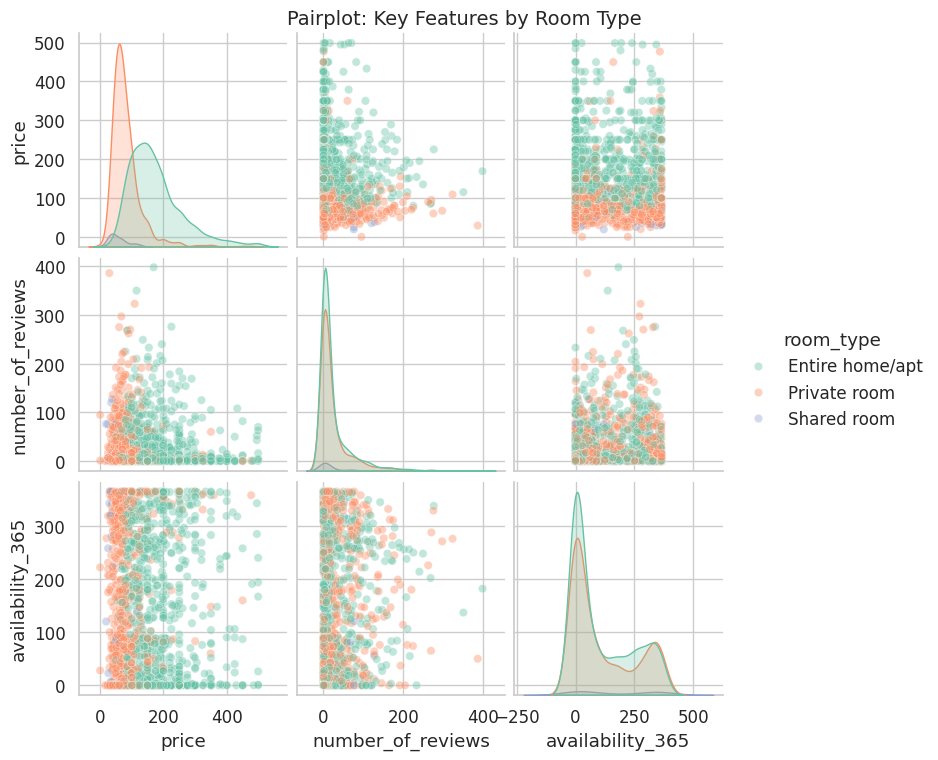

In [17]:
# ── 5.2 Pairplot (Key Features) ───────────────────────────
sample = df[df['price'] < 500].sample(2000, random_state=42)
sns.pairplot(
    sample[['price','number_of_reviews','availability_365','room_type']],
    hue='room_type', palette='Set2', diag_kind='kde', plot_kws={'alpha':0.4}
)
plt.suptitle('Pairplot: Key Features by Room Type', y=1.01, fontsize=14)
plt.show()

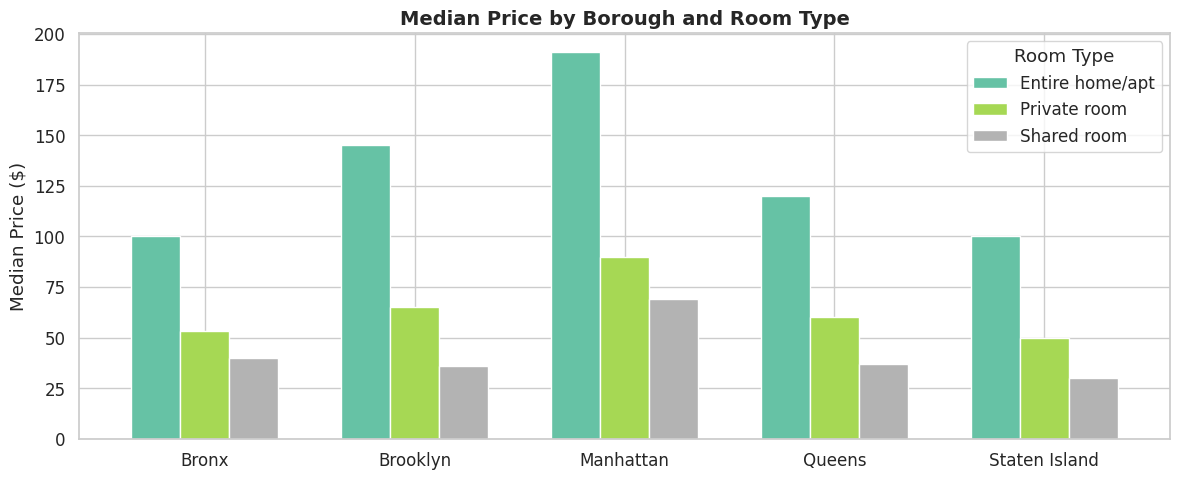

In [18]:
# ── 5.3 Grouped Analysis: Mean Price by Borough × Room Type
pivot = df.groupby(['neighbourhood_group','room_type'])['price'].median().unstack()

fig, ax = plt.subplots(figsize=(12, 5))
pivot.plot(kind='bar', ax=ax, colormap='Set2', edgecolor='white', width=0.7)
ax.set_title('Median Price by Borough and Room Type')
ax.set_ylabel('Median Price ($)')
ax.set_xlabel('')
ax.legend(title='Room Type', bbox_to_anchor=(1, 1))
ax.tick_params(axis='x', rotation=0)
plt.tight_layout()
plt.show()

# 🗺️ Phase 6 — Geographic Analysis

In [19]:
# ── 6.1 Listing Density Map ───────────────────────────────
fig = px.scatter_mapbox(
    df.sample(10000, random_state=42),
    lat='latitude', lon='longitude',
    color='neighbourhood_group',
    size='price', size_max=10,
    hover_data=['name','price','room_type'],
    mapbox_style='carto-positron',
    zoom=10, opacity=0.5,
    title='NYC Airbnb Listing Density by Borough',
    color_discrete_sequence=px.colors.qualitative.Set2
)
fig.update_layout(margin=dict(l=0, r=0, t=40, b=0))
fig.show()

In [20]:
# ── 6.2 Price Heatmap ─────────────────────────────────────
fig = px.density_mapbox(
    df[df['price'] < 500],
    lat='latitude', lon='longitude',
    z='price', radius=10,
    mapbox_style='carto-positron',
    zoom=10, opacity=0.7,
    title='Price Density Heatmap across NYC',
    color_continuous_scale='YlOrRd'
)
fig.update_layout(margin=dict(l=0, r=0, t=40, b=0))
fig.show()

# 🔎 Phase 7 — Outlier Detection

In [21]:
# ── 7.1 IQR Method ───────────────────────────────────────
def detect_outliers_iqr(series, label):
    Q1 = series.quantile(0.25)
    Q3 = series.quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    n_out = ((series < lower) | (series > upper)).sum()
    print(f"{label}: Q1={Q1:.1f}, Q3={Q3:.1f}, IQR={IQR:.1f}, "
          f"bounds=[{lower:.1f}, {upper:.1f}], outliers={n_out} ({n_out/len(series)*100:.1f}%)")
    return lower, upper

lo_p, hi_p = detect_outliers_iqr(df['price'], 'Price')
lo_n, hi_n = detect_outliers_iqr(df['minimum_nights'], 'Minimum Nights')

Price: Q1=69.0, Q3=175.0, IQR=106.0, bounds=[-90.0, 334.0], outliers=2972 (6.1%)
Minimum Nights: Q1=1.0, Q3=5.0, IQR=4.0, bounds=[-5.0, 11.0], outliers=6607 (13.5%)


In [22]:
# ── 7.2 Extreme Prices ────────────────────────────────────
print("--- Top 10 Most Expensive Listings ---")
print(df.nlargest(10, 'price')[['name','neighbourhood_group','room_type','price']])

print("\n--- Listings with price = $0 ---")
print(df[df['price'] == 0][['name','neighbourhood_group','room_type','price']])

--- Top 10 Most Expensive Listings ---
                                                    name neighbourhood_group  \
9151                 Furnished room in Astoria apartment              Queens   
17692    Luxury 1 bedroom apt. -stunning Manhattan views            Brooklyn   
29238                                1-BR Lincoln Center           Manhattan   
6530                                  Spanish Harlem Apt           Manhattan   
12342                Quiet, Clean, Lit @ LES & Chinatown           Manhattan   
40433  2br - The Heart of NYC: Manhattans Lower East ...           Manhattan   
30268  Beautiful/Spacious 1 bed luxury flat-TriBeCa/Soho           Manhattan   
4377                                       Film Location            Brooklyn   
29662          East 72nd Townhouse by (Hidden by Airbnb)           Manhattan   
42523                70' Luxury MotorYacht on the Hudson           Manhattan   

             room_type  price  
9151      Private room  10000  
17692  Entire ho

In [23]:
# ── 7.3 Minimum Nights Anomalies ─────────────────────────
print(f"Listings requiring > 365 nights minimum: {(df['minimum_nights'] > 365).sum()}")
print(f"Listings requiring > 30 nights minimum:  {(df['minimum_nights'] > 30).sum()}")

# These are likely mis-entered or fraudulent listings — worth flagging

Listings requiring > 365 nights minimum: 14
Listings requiring > 30 nights minimum:  747


# 📅 Phase 8 — Review and Availability Patterns

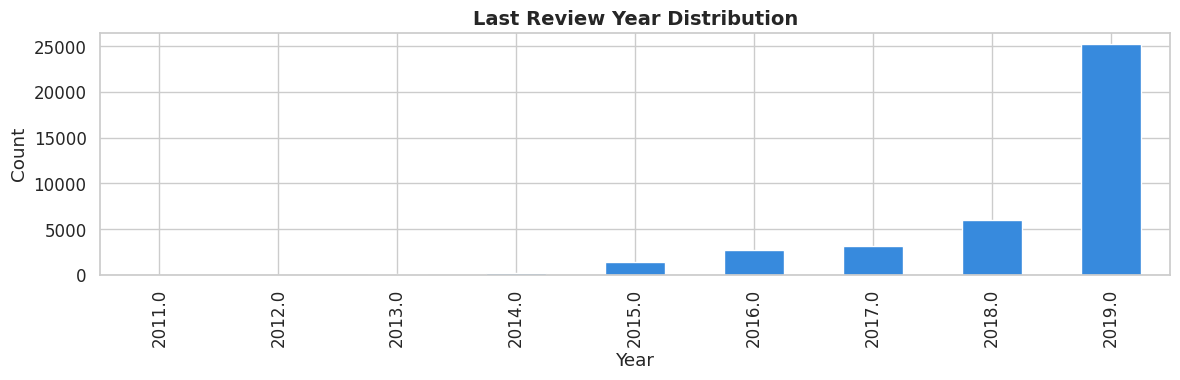

In [24]:
# ── 8.1 Reviews Over Time ─────────────────────────────────
df['last_review_year'] = df['last_review'].dt.year

yearly = df['last_review_year'].value_counts().sort_index()

fig, ax = plt.subplots(figsize=(12, 4))
yearly.plot(kind='bar', ax=ax, color='#378ADD', edgecolor='white')
ax.set_title('Last Review Year Distribution')
ax.set_xlabel('Year')
ax.set_ylabel('Count')
plt.tight_layout()
plt.show()

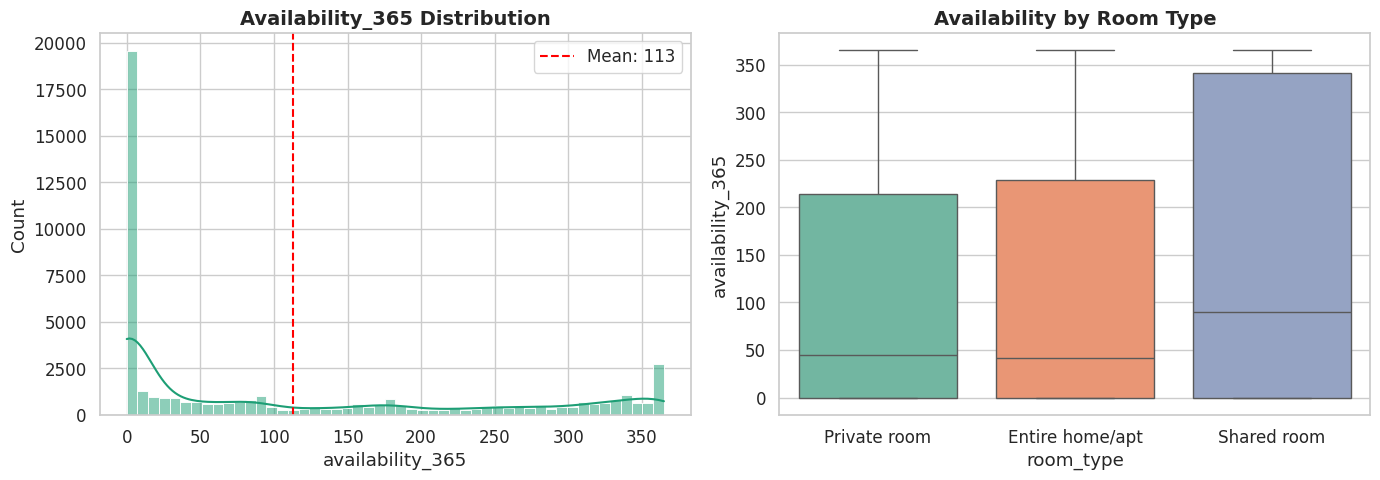

In [25]:
# ── 8.2 Availability Distribution ────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(df['availability_365'], bins=50, kde=True, 
             ax=axes[0], color='#1D9E75')
axes[0].set_title('Availability_365 Distribution')
axes[0].axvline(df['availability_365'].mean(), color='red',
                linestyle='--', label=f"Mean: {df['availability_365'].mean():.0f}")
axes[0].legend()

# Availability by room type
sns.boxplot(data=df, x='room_type', y='availability_365', 
            ax=axes[1], palette='Set2')
axes[1].set_title('Availability by Room Type')

plt.tight_layout()
plt.show()

# 💡 Phase 9 — Business Insights Summary

In [26]:
# ── Final Summary ─────────────────────────────────────────
insights = {
    'Total Listings': len(df),
    'Median Price': f"${df['price'].median():.0f}",
    'Most Common Room Type': df['room_type'].mode()[0],
    'Top Borough': df['neighbourhood_group'].mode()[0],
    'Never Reviewed %': f"{df['last_review'].isna().mean()*100:.1f}%",
    'Avg Availability (days/yr)': f"{df['availability_365'].mean():.0f}",
    'Price Outliers (IQR)': f"{((df['price'] > hi_p) | (df['price'] < lo_p)).sum()}",
    'Multi-listing Hosts': f"{(df['calculated_host_listings_count'] > 1).sum():,}",
}

for k, v in insights.items():
    print(f"  {'·'} {k:<35} {v}")

  · Total Listings                      48895
  · Median Price                        $106
  · Most Common Room Type               Entire home/apt
  · Top Borough                         Manhattan
  · Never Reviewed %                    20.6%
  · Avg Availability (days/yr)          113
  · Price Outliers (IQR)                2972
  · Multi-listing Hosts                 16,592


## ✅ Notebook Closing Cell

## Key Findings

| Finding | Detail |
|---|---|
| Price is heavily right-skewed | Median ~$106, but max ~$10,000 |
| Manhattan commands highest prices | Especially Entire home/apt |
| 20.5% listings never reviewed | Possible quality or activity signal |
| Shared rooms are rare (2.4%) | Market dominated by entire homes |
| Some hosts list 300+ properties | Signals commercial/professional hosts |
| Minimum nights > 365 exist | Data quality issue worth cleaning |

## Next Steps
- Feature engineering for price prediction
- Time series on review activity
- Clustering neighbourhoods by price tier
- Predicting high-demand listings